In [16]:
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from particletracker.fileparser import field_function_from_file
from particletracker.trajectory import solve_trajectory
from particletracker.trajanalysis import show_deviation_degree, show_deviation_in_Z, plot_2d_trajectory, plot_3d_trajectory

In [ ]:
''' ==== Particle features ==== '''
m = 939.3      # proton mass (MeV/c²)
q = 1          # proton charge (elementary charge)



''' === Initial conditions === '''
x0, y0, z0 = -0.07573, 0, -0.35   # initial coordinates (m)
v_direction = [((6**0.5)-(2**0.5))/4, 0, ((6**0.5)+(2**0.5))/4]    # velocity vector
Ec0 = 2                   # initial particle's kinetic energy 


''' === Trajectory solution === '''
method = 'boris'            # choose between "boris" and "rk4"
total_t = 1e-6              # total elapsed time (s)
step_list = [total_t/1e6,  total_t/1e5, total_t/1e4, total_t/1e3, total_t/1e2]              # time step (s)

traj_distance = 0.685761        # total distance of particle's trajectory in X axis (m)



''' === Fields === '''
e_field = lambda ponto: [0, 0, 0]       # force electric field to be 0 at all points

file = '2026-01-19_LDE05_Fieldmap_X=-130_130mm_Z=-350_350mm_Imc=12.5A_ID=5479.dat'

desired_x = -0.071212
desired_z = 0.335761


colors = ['red', 'blue', 'green', 'orange']

tempo total = 3e-07
Z1 = 0.3442022100338388
The final x value is approximately -0.07125095299331846
tempo total = 8e-07
Z1 = 0.3696600096423784
The final x value is approximately -0.07142002883223413
tempo total = 1e-06
Z1 = 0.3357748659625271
The final x value is approximately -0.07079444020893155


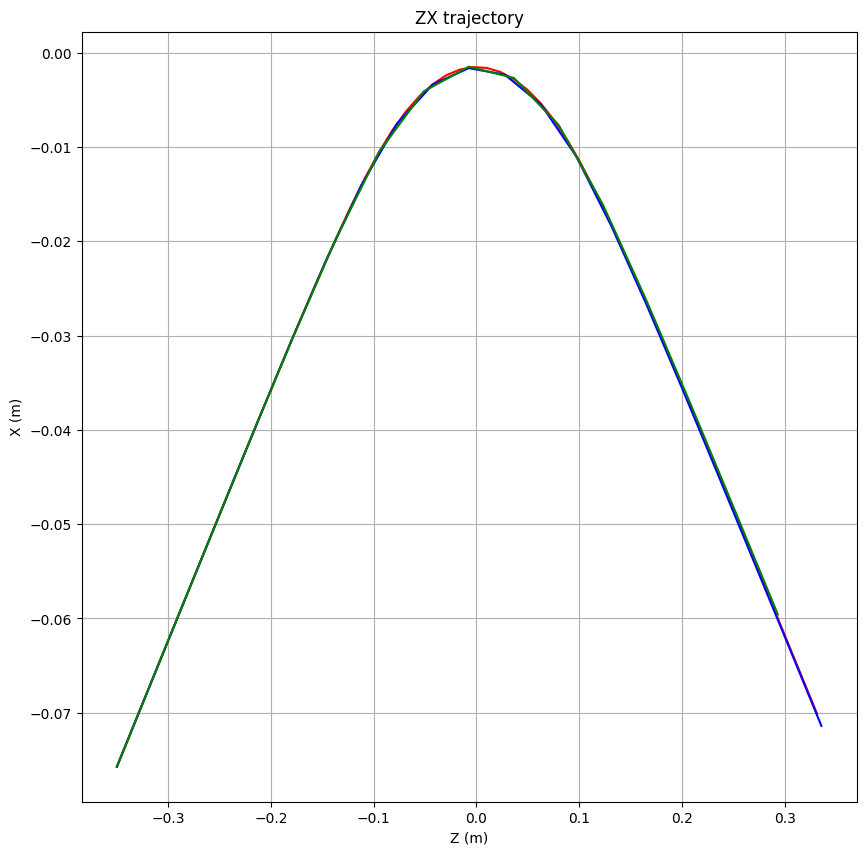

In [ ]:
b_field = field_function_from_file(file, '\t', 17)
fig = plt.figure(figsize=(10, 10))
plt.xlabel('Z (m)')
plt.ylabel('X (m)')
plt.grid(True)
plt.axis()
plt.title('ZX trajectory')

for total_t, color in zip(, colors):
    print(f'tempo total = {total_t}')

    step = total_t/100 
    
    df = solve_trajectory(m, q, 
                            x0, y0, z0, v_direction, Ec0,
                            b_field, e_field,
                            method, step, total_t, 
                            output_file='traj_calculation_results')

    final_x = show_deviation_in_Z(df, desired_z)

    condition = df['z(m)'] > (traj_distance-abs(df['z(m)'].iloc[0]))
    result = df.drop(df[condition].index)

    plt.plot(result['z(m)'], result['x(m)'], color, linewidth=1.5)

    print('=====================')